In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df

,CGP,Package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package')

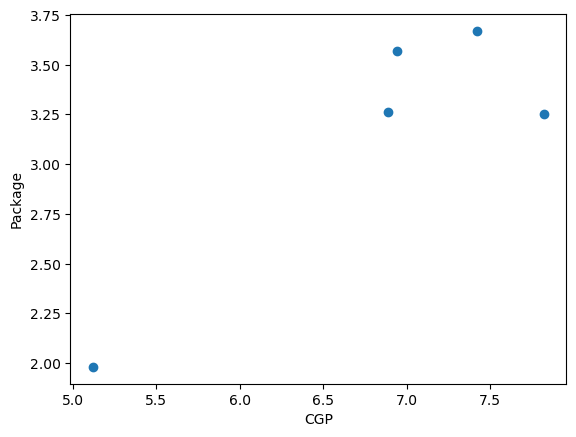

In [4]:
plt.scatter(df['CGP'],df['Package'])
plt.xlabel('CGP')
plt.ylabel('Package')

In [5]:
x = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [6]:
y

0    3.26
1    1.98
2    3.25
3    3.67
4    3.57
Name: Package, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr = LinearRegression()

In [11]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
x_train

,CGP
4,6.94
1,5.12
3,7.42
0,6.89


In [13]:
lr.predict(x_train.iloc[0].values.reshape(1,1))

f:\Data_Science\envs\booksenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.38460736])

In [14]:
lr.predict(x_test.iloc[0].values.reshape(1,1))


f:\Data_Science\envs\booksenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([4.05469218])

Text(0, 0.5, 'Package')

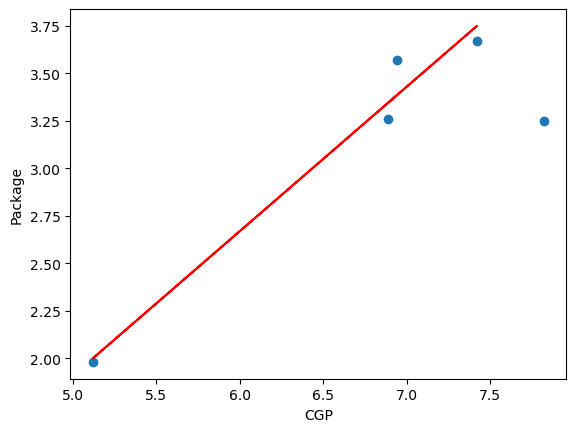

In [15]:
plt.scatter(df['CGP'],df['Package'])
plt.plot(x_train,lr.predict(x_train),color='red')
plt.xlabel('CGP')
plt.ylabel('Package')

In [16]:
m = lr.coef_

In [17]:
b = lr.intercept_

In [18]:
# y = mx+b
# here our trained data will give output for any input
m * 9.5 + b

array([5.33394502])

In [ ]:
lr

In [19]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [23]:
y_pred =lr.predict(x_test)

In [24]:
y_test.values

array([3.25])

In [25]:
print("Mean absolute error : ",mean_absolute_error(y_test,y_pred))

Mean absolute error :  0.8046921814663932


In [26]:
print("Mean squared error : ",mean_squared_error(y_test,y_pred))


Mean squared error :  0.6475295069131427


In [28]:
print("RMSE : ",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE :  0.8046921814663932


In [29]:
print("MSE : ",r2_score(y_test,y_pred))

MSE :  nan


f:\Data_Science\envs\booksenv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
